# **🧠 Brain Tumor Segmentation using U-Net**

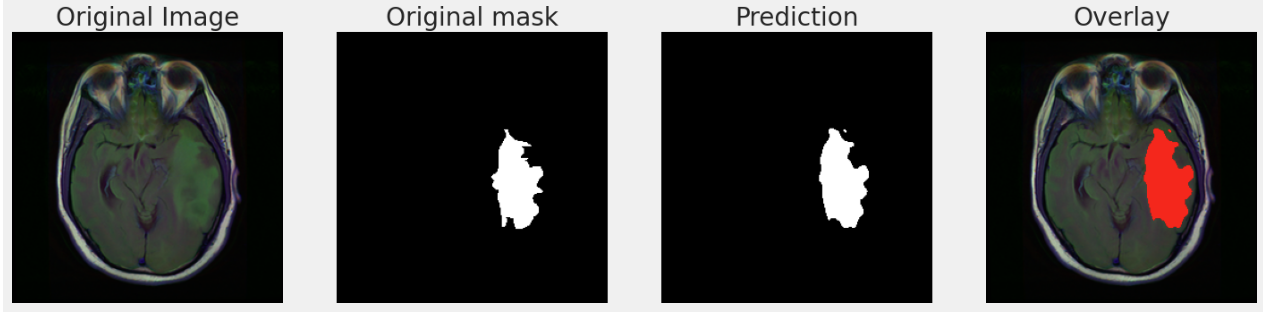

# 📌 Overview

This project focuses on automatic brain tumor segmentation from MRI images using a Deep Learning model based on the U-Net architecture.

The goal is to help in medical image analysis by accurately detecting and segmenting tumor regions in brain MRI scans.

U-Net is widely used in medical image segmentation because it can capture both context and precise localization.

# 🎯 Objectives

- Detect tumor regions in MRI brain scans

- Generate pixel-level segmentation masks

- Improve medical image analysis using deep learning techniques

In [2]:
# import system libs
import os
import time
import random
import pathlib
import itertools
from glob import glob

# import data handling tools
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
%matplotlib inline
from skimage.color import rgb2gray
from skimage.morphology import label
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from skimage.io import imread, imshow, concatenate_images

# import Deep learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model, load_model, save_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Input, Activation, BatchNormalization, Dropout, Lambda, Conv2D, Conv2DTranspose, MaxPooling2D, concatenate

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")
print ('modules loaded')

modules loaded


# **Create needed Functions**

## 1. Function to create dataframe from dataset

In [2]:
# function to create dataframe
def create_df(data_dir):
    images_paths = []
    masks_paths = glob(f'{data_dir}/*/*_mask*')

    for i in masks_paths:
        images_paths.append(i.replace('_mask', ''))
    df = pd.DataFrame(data= {'images_paths': images_paths, 'masks_paths': masks_paths})
    return df

# Function to split dataframe into train, valid, test
def split_df(df):
    # create train_df
    train_df, dummy_df = train_test_split(df, train_size= 0.8, random_state=42, shuffle=True)

    # create valid_df and test_df
    valid_df, test_df = train_test_split(dummy_df, train_size= 0.5, random_state=42)
    return train_df, valid_df, test_df

## 2. Function to create image generators and augmentation 

In [3]:
def create_gens(df, aug_dict):
    img_size = (256, 256)
    batch_size = 30

    img_gen = ImageDataGenerator(**aug_dict)
    msk_gen = ImageDataGenerator(**aug_dict)

    # Create general generator
    image_gen = img_gen.flow_from_dataframe(df, x_col='images_paths', class_mode=None, color_mode='rgb', target_size=img_size,
                                            batch_size=batch_size, save_to_dir=None, save_prefix='image', seed=1)

    mask_gen = msk_gen.flow_from_dataframe(df, x_col='masks_paths', class_mode=None, color_mode='grayscale', target_size=img_size,
                                            batch_size=batch_size, save_to_dir=None, save_prefix= 'mask', seed=1)
    gen = zip(image_gen, mask_gen)

    for (img, msk) in gen:
        img = img / 255
        msk = msk / 255
        msk[msk > 0.5] = 1
        msk[msk <= 0.5] = 0
        
        yield (img, msk)

## 3. Function that have U-Net structure 

![U-Net](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/u-net-architecture.png)


# Basic U_Net

In [4]:
# def unet(input_size=(256, 256, 3)):
#     inputs = Input(input_size)

#     # First DownConvolution / Encoder Leg will begin, so start with Conv2D
#     conv1 = Conv2D(filters=64, kernel_size=(3, 3), padding="same")(inputs)
#     bn1 = Activation("relu")(conv1)
#     conv1 = Conv2D(filters=64, kernel_size=(3, 3), padding="same")(bn1)
#     bn1 = BatchNormalization(axis=3)(conv1)
#     bn1 = Activation("relu")(bn1)
#     pool1 = MaxPooling2D(pool_size=(2, 2))(bn1)

#     conv2 = Conv2D(filters=128, kernel_size=(3, 3), padding="same")(pool1)
#     bn2 = Activation("relu")(conv2)
#     conv2 = Conv2D(filters=128, kernel_size=(3, 3), padding="same")(bn2)
#     bn2 = BatchNormalization(axis=3)(conv2)
#     bn2 = Activation("relu")(bn2)
#     pool2 = MaxPooling2D(pool_size=(2, 2))(bn2)

#     conv3 = Conv2D(filters=256, kernel_size=(3, 3), padding="same")(pool2)
#     bn3 = Activation("relu")(conv3)
#     conv3 = Conv2D(filters=256, kernel_size=(3, 3), padding="same")(bn3)
#     bn3 = BatchNormalization(axis=3)(conv3)
#     bn3 = Activation("relu")(bn3)
#     pool3 = MaxPooling2D(pool_size=(2, 2))(bn3)

#     conv4 = Conv2D(filters=512, kernel_size=(3, 3), padding="same")(pool3)
#     bn4 = Activation("relu")(conv4)
#     conv4 = Conv2D(filters=512, kernel_size=(3, 3), padding="same")(bn4)
#     bn4 = BatchNormalization(axis=3)(conv4)
#     bn4 = Activation("relu")(bn4)
#     pool4 = MaxPooling2D(pool_size=(2, 2))(bn4)

#     conv5 = Conv2D(filters=1024, kernel_size=(3, 3), padding="same")(pool4)
#     bn5 = Activation("relu")(conv5)
#     conv5 = Conv2D(filters=1024, kernel_size=(3, 3), padding="same")(bn5)
#     bn5 = BatchNormalization(axis=3)(conv5)
#     bn5 = Activation("relu")(bn5)

#     """ Now UpConvolution / Decoder Leg will begin, so start with Conv2DTranspose
#     The gray arrows (in the above image) indicate the skip connections that concatenate the encoder feature map with the decoder, which helps the backward flow of gradients for improved training. """
#     """ After every concatenation we again apply two consecutive regular convolutions so that the model can learn to assemble a more precise output """

#     up6 = concatenate([Conv2DTranspose(512, kernel_size=(2, 2), strides=(2, 2), padding="same")(bn5), conv4], axis=3)
#     conv6 = Conv2D(filters=512, kernel_size=(3, 3), padding="same")(up6)
#     bn6 = Activation("relu")(conv6)
#     conv6 = Conv2D(filters=512, kernel_size=(3, 3), padding="same")(bn6)
#     bn6 = BatchNormalization(axis=3)(conv6)
#     bn6 = Activation("relu")(bn6)

#     up7 = concatenate([Conv2DTranspose(256, kernel_size=(2, 2), strides=(2, 2), padding="same")(bn6), conv3], axis=3)
#     conv7 = Conv2D(filters=256, kernel_size=(3, 3), padding="same")(up7)
#     bn7 = Activation("relu")(conv7)
#     conv7 = Conv2D(filters=256, kernel_size=(3, 3), padding="same")(bn7)
#     bn7 = BatchNormalization(axis=3)(conv7)
#     bn7 = Activation("relu")(bn7)

#     up8 = concatenate([Conv2DTranspose(128, kernel_size=(2, 2), strides=(2, 2), padding="same")(bn7), conv2], axis=3)
#     conv8 = Conv2D(filters=128, kernel_size=(3, 3), padding="same")(up8)
#     bn8 = Activation("relu")(conv8)
#     conv8 = Conv2D(filters=128, kernel_size=(3, 3), padding="same")(bn8)
#     bn8 = BatchNormalization(axis=3)(conv8)
#     bn8 = Activation("relu")(bn8)

#     up9 = concatenate([Conv2DTranspose(64, kernel_size=(2, 2), strides=(2, 2), padding="same")(bn8), conv1], axis=3)
#     conv9 = Conv2D(filters=64, kernel_size=(3, 3), padding="same")(up9)
#     bn9 = Activation("relu")(conv9)
#     conv9 = Conv2D(filters=64, kernel_size=(3, 3), padding="same")(bn9)
#     bn9 = BatchNormalization(axis=3)(conv9)
#     bn9 = Activation("relu")(bn9)

#     conv10 = Conv2D(filters=1, kernel_size=(1, 1), activation="sigmoid")(bn9)

#     return Model(inputs=[inputs], outputs=[conv10])

# Improved model architecture

In [5]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose
from tensorflow.keras.layers import BatchNormalization, Activation, Dropout, concatenate, LeakyReLU

def conv_block(x, filters, dropout=False):
    
    """ convolutional block: Conv → BN → LeakyReLU → Conv → BN → LeakyReLU """
    
    x = Conv2D(filters, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.1)(x)
    
    x = Conv2D(filters, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.1)(x)
    
    if dropout:
        x = Dropout(0.3)(x)  # Helps prevent overfitting
    return x

def improved_unet(input_size=(256, 256, 3)):
    inputs = Input(input_size)
    
    """ First DownConvolution / Encoder Leg will begin, so start with Conv2D 'Sampling' """

    c1 = conv_block(inputs, 64)
    p1 = MaxPooling2D((2,2))(c1)
    
    c2 = conv_block(p1, 128)
    p2 = MaxPooling2D((2,2))(c2)
    
    c3 = conv_block(p2, 256)
    p3 = MaxPooling2D((2,2))(c3)
    
    c4 = conv_block(p3, 512, dropout=True)
    p4 = MaxPooling2D((2,2))(c4)
    
    c5 = conv_block(p4, 1024, dropout=True)
    
    """ Now UpConvolution / Decoder Leg will begin, so start with Conv2DTranspose 'Sampling' """
    
    u6 = Conv2DTranspose(512, (2,2), strides=(2,2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = conv_block(u6, 512)
    
    u7 = Conv2DTranspose(256, (2,2), strides=(2,2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = conv_block(u7, 256)
    
    u8 = Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = conv_block(u8, 128)
    
    u9 = Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(c8)
    u9 = concatenate([u9, c1])
    c9 = conv_block(u9, 64)
    
    outputs = Conv2D(1, (1,1), activation='sigmoid')(c9)
    
    model = Model(inputs=[inputs], outputs=[outputs])
    return model

In [7]:

""" Dice - dice loss - IoU - Precision - Recall - (Dice + BCE) """

# Dice Coefficient

def dice_coef(y_true, y_pred, smooth=100):
    y_true = K.flatten(y_true)
    y_pred = K.flatten(y_pred)
    
    intersection = K.sum(y_true * y_pred)
    return (2. * intersection + smooth) / (K.sum(y_true) + K.sum(y_pred) + smooth)

# Dice Loss

def dice_loss(y_true, y_pred,smooth=100):
    
    return 1 - dice_coef(y_true, y_pred, smooth)

# IoU (Intersection over Union)

def iou_coef(y_true, y_pred, smooth=100):
    y_true = K.flatten(y_true)
    y_pred = K.flatten(y_pred)

    intersection = K.sum(y_true * y_pred)
    union = K.sum(y_true) + K.sum(y_pred) - intersection

    return (intersection + smooth) / (union + smooth)

# Precision

def precision_m(y_true, y_pred):
    y_true = K.flatten(y_true)
    y_pred = K.flatten(y_pred)

    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))

    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

# Recall

def recall_m(y_true, y_pred):
    y_true = K.flatten(y_true)
    y_pred = K.flatten(y_pred)

    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))

    recall = true_positives / (possible_positives + K.epsilon())
    return recall

# Combined Loss (Dice + BCE)

def bce_dice_loss(y_true, y_pred):

    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice

## 5. Function to show images sample

In [8]:
def show_images(images, masks):
    plt.figure(figsize=(12, 12))
    for i in range(12):
        plt.subplot(3, 4, i+1)
        img_path = images[i]
        mask_path = masks[i]
        # read image and convert it to RGB scale
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        # read mask
        mask = cv2.imread(mask_path)
        # sho image and mask
        plt.imshow(image)
        plt.imshow(mask, alpha=0.4)

        plt.axis('off')

    plt.tight_layout()
    plt.show()

## 6. Function to display training history

In [9]:
def plot_training(hist):

    # Training metrics
    tr_iou = hist.history['iou_coef']
    tr_dice = hist.history['dice_coef']
    tr_precision = hist.history['precision_m']
    tr_recall = hist.history['recall_m']
    tr_loss = hist.history['loss']

    # Validation metrics
    val_iou = hist.history['val_iou_coef']
    val_dice = hist.history['val_dice_coef']
    val_precision = hist.history['val_precision_m']
    val_recall = hist.history['val_recall_m']
    val_loss = hist.history['val_loss']

    # Best epochs
    index_iou = np.argmax(val_iou)
    index_dice = np.argmax(val_dice)
    index_precision = np.argmax(val_precision)
    index_recall = np.argmax(val_recall)
    index_loss = np.argmin(val_loss)

    Epochs = [i + 1 for i in range(len(tr_loss))]

    plt.figure(figsize=(20,20))
    plt.style.use('fivethirtyeight')

    # IoU
    plt.subplot(2,3,1)
    plt.plot(Epochs, tr_iou, label='Training IoU')
    plt.plot(Epochs, val_iou, label='Validation IoU')
    plt.scatter(index_iou+1, val_iou[index_iou], s=150, label=f'Best Epoch = {index_iou+1}')
    plt.title('Training & Validation IoU')
    plt.xlabel('Epochs')
    plt.ylabel('IoU')
    plt.legend()

    # Dice
    plt.subplot(2,3,2)
    plt.plot(Epochs, tr_dice, label='Training Dice')
    plt.plot(Epochs, val_dice, label='Validation Dice')
    plt.scatter(index_dice+1, val_dice[index_dice], s=150, label=f'Best Epoch = {index_dice+1}')
    plt.title('Training & Validation Dice')
    plt.xlabel('Epochs')
    plt.ylabel('Dice')
    plt.legend()

    # Precision
    plt.subplot(2,3,3)
    plt.plot(Epochs, tr_precision, label='Training Precision')
    plt.plot(Epochs, val_precision, label='Validation Precision')
    plt.scatter(index_precision+1, val_precision[index_precision], s=150, label=f'Best Epoch = {index_precision+1}')
    plt.title('Training & Validation Precision')
    plt.xlabel('Epochs')
    plt.ylabel('Precision')
    plt.legend()

    # Recall
    plt.subplot(2,3,4)
    plt.plot(Epochs, tr_recall, label='Training Recall')
    plt.plot(Epochs, val_recall, label='Validation Recall')
    plt.scatter(index_recall+1, val_recall[index_recall], s=150, label=f'Best Epoch = {index_recall+1}')
    plt.title('Training & Validation Recall')
    plt.xlabel('Epochs')
    plt.ylabel('Recall')
    plt.legend()

    # Loss
    plt.subplot(2,3,5)
    plt.plot(Epochs, tr_loss, label='Training Loss')
    plt.plot(Epochs, val_loss, label='Validation Loss')
    plt.scatter(index_loss+1, val_loss[index_loss], s=150, label=f'Best Epoch = {index_loss+1}')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# **Model Structure**

## Start Reading Data Improved

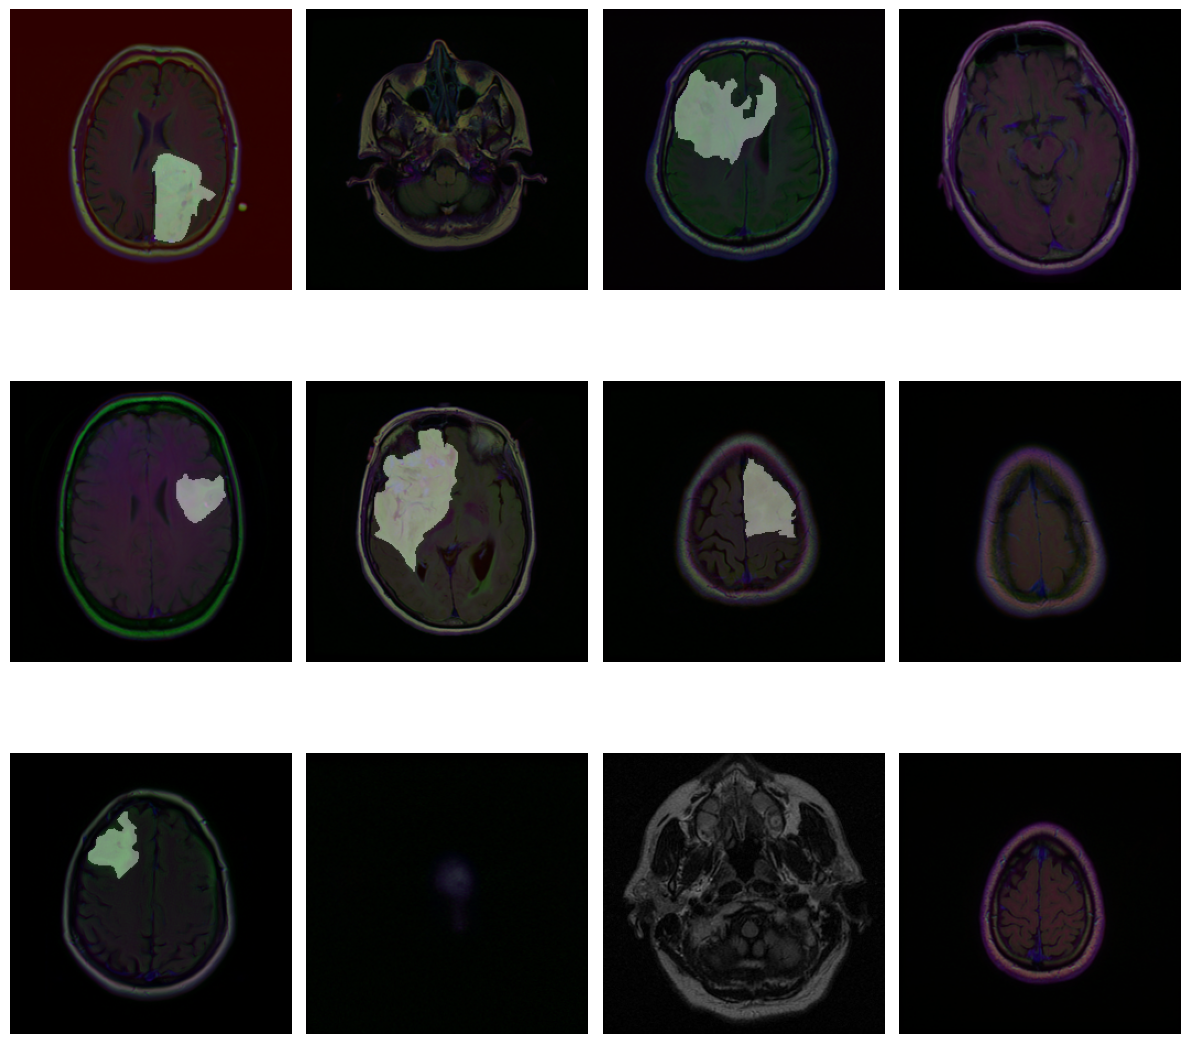

In [10]:
data_dir = '/kaggle/input/lgg-mri-segmentation/kaggle_3m'

df = create_df(data_dir)
train_df, valid_df, test_df = split_df(df)

tr_aug_dict = dict(rotation_range=15,
                            width_shift_range=0.2,
                            height_shift_range=0.2,
                            shear_range=0.2,
                            zoom_range=0.3,
                            horizontal_flip=True,
                            vertical_flip=True,
                            fill_mode='nearest'
                  )
train_gen = create_gens(train_df, aug_dict=tr_aug_dict)
valid_gen = create_gens(valid_df, aug_dict={})
test_gen = create_gens(test_df, aug_dict={})

show_images(list(train_df['images_paths']), list(train_df['masks_paths']))

## U-Net Model

In [11]:
model = improved_unet()
model.compile(Adamax(learning_rate=1e-4), loss= dice_loss, metrics= [dice_coef, iou_coef, precision_m, recall_m])

model.summary()

I0000 00:00:1773574865.953351      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ leaky_re_lu[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ leaky_re_lu_1[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ leaky_re_lu_2[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ leaky_re_lu_3[0]… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,055,297 (118.47 MB)

 Trainable params: 31,043,521 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

## Model Training

In [12]:
epochs = 100
batch_size = 30
callbacks = [ModelCheckpoint('improved_unet2.keras', verbose=0, save_best_only=True)
                ,EarlyStopping(patience=10, restore_best_weights=True)]

history = model.fit(
    train_gen,
    steps_per_epoch=int(len(train_df) / batch_size),
    epochs=epochs,
    verbose=1,
    callbacks=callbacks,
    validation_data=valid_gen,
    validation_steps=int(len(valid_df) / batch_size)
)

Found 3143 validated image filenames.
Found 3143 validated image filenames.
Epoch 1/100


I0000 00:00:1773574891.151344     103 service.cc:148] XLA service 0x786ebc004350 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773574891.153102     103 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773574892.476868     103 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1773574899.519181     103 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1773574899.759741     103 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1773574901.117470     103 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1773574901.3827

104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 896ms/step - dice_coef: 0.0481 - iou_coef: 0.0249 - loss: 0.9519 - precision_m: 0.0349 - recall_m: 0.9813Found 393 validated image filenames.
Found 393 validated image filenames.
104/104 ━━━━━━━━━━━━━━━━━━━━ 180s 982ms/step - dice_coef: 0.0483 - iou_coef: 0.0250 - loss: 0.9517 - precision_m: 0.0351 - recall_m: 0.9811 - val_dice_coef: 0.0205 - val_iou_coef: 0.0104 - val_loss: 0.9795 - val_precision_m: 0.0101 - val_recall_m: 1.0000
Epoch 2/100


E0000 00:00:1773575060.333551     101 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1773575060.572651     101 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1773575061.829631     101 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1773575062.092964     101 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


104/104 ━━━━━━━━━━━━━━━━━━━━ 126s 735ms/step - dice_coef: 0.0983 - iou_coef: 0.0521 - loss: 0.9017 - precision_m: 0.1467 - recall_m: 0.9401 - val_dice_coef: 0.0101 - val_iou_coef: 0.0051 - val_loss: 0.9899 - val_precision_m: 9.3312e-05 - val_recall_m: 0.0030
Epoch 3/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 697ms/step - dice_coef: 0.1256 - iou_coef: 0.0679 - loss: 0.8743 - precision_m: 0.2682 - recall_m: 0.9324

E0000 00:00:1773575255.614584     102 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1773575255.869601     102 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


104/104 ━━━━━━━━━━━━━━━━━━━━ 80s 768ms/step - dice_coef: 0.1256 - iou_coef: 0.0678 - loss: 0.8744 - precision_m: 0.2683 - recall_m: 0.9324 - val_dice_coef: 0.0114 - val_iou_coef: 0.0059 - val_loss: 0.9879 - val_precision_m: 1.3387e-04 - val_recall_m: 0.0014
Epoch 4/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 81s 781ms/step - dice_coef: 0.1345 - iou_coef: 0.0730 - loss: 0.8646 - precision_m: 0.2969 - recall_m: 0.9044 - val_dice_coef: 0.0308 - val_iou_coef: 0.0159 - val_loss: 0.9671 - val_precision_m: 0.1026 - val_recall_m: 0.1988
Epoch 5/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 77s 742ms/step - dice_coef: 0.1352 - iou_coef: 0.0734 - loss: 0.8643 - precision_m: 0.2931 - recall_m: 0.8497 - val_dice_coef: 0.1396 - val_iou_coef: 0.0783 - val_loss: 0.8821 - val_precision_m: 0.4451 - val_recall_m: 0.7088
Epoch 6/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 77s 742ms/step - dice_coef: 0.1594 - iou_coef: 0.0877 - loss: 0.8405 - precision_m: 0.3727 - recall_m: 0.9355 - val_dice_coef: 0.1506 - val_iou_coef: 0.0829 - val_loss: 

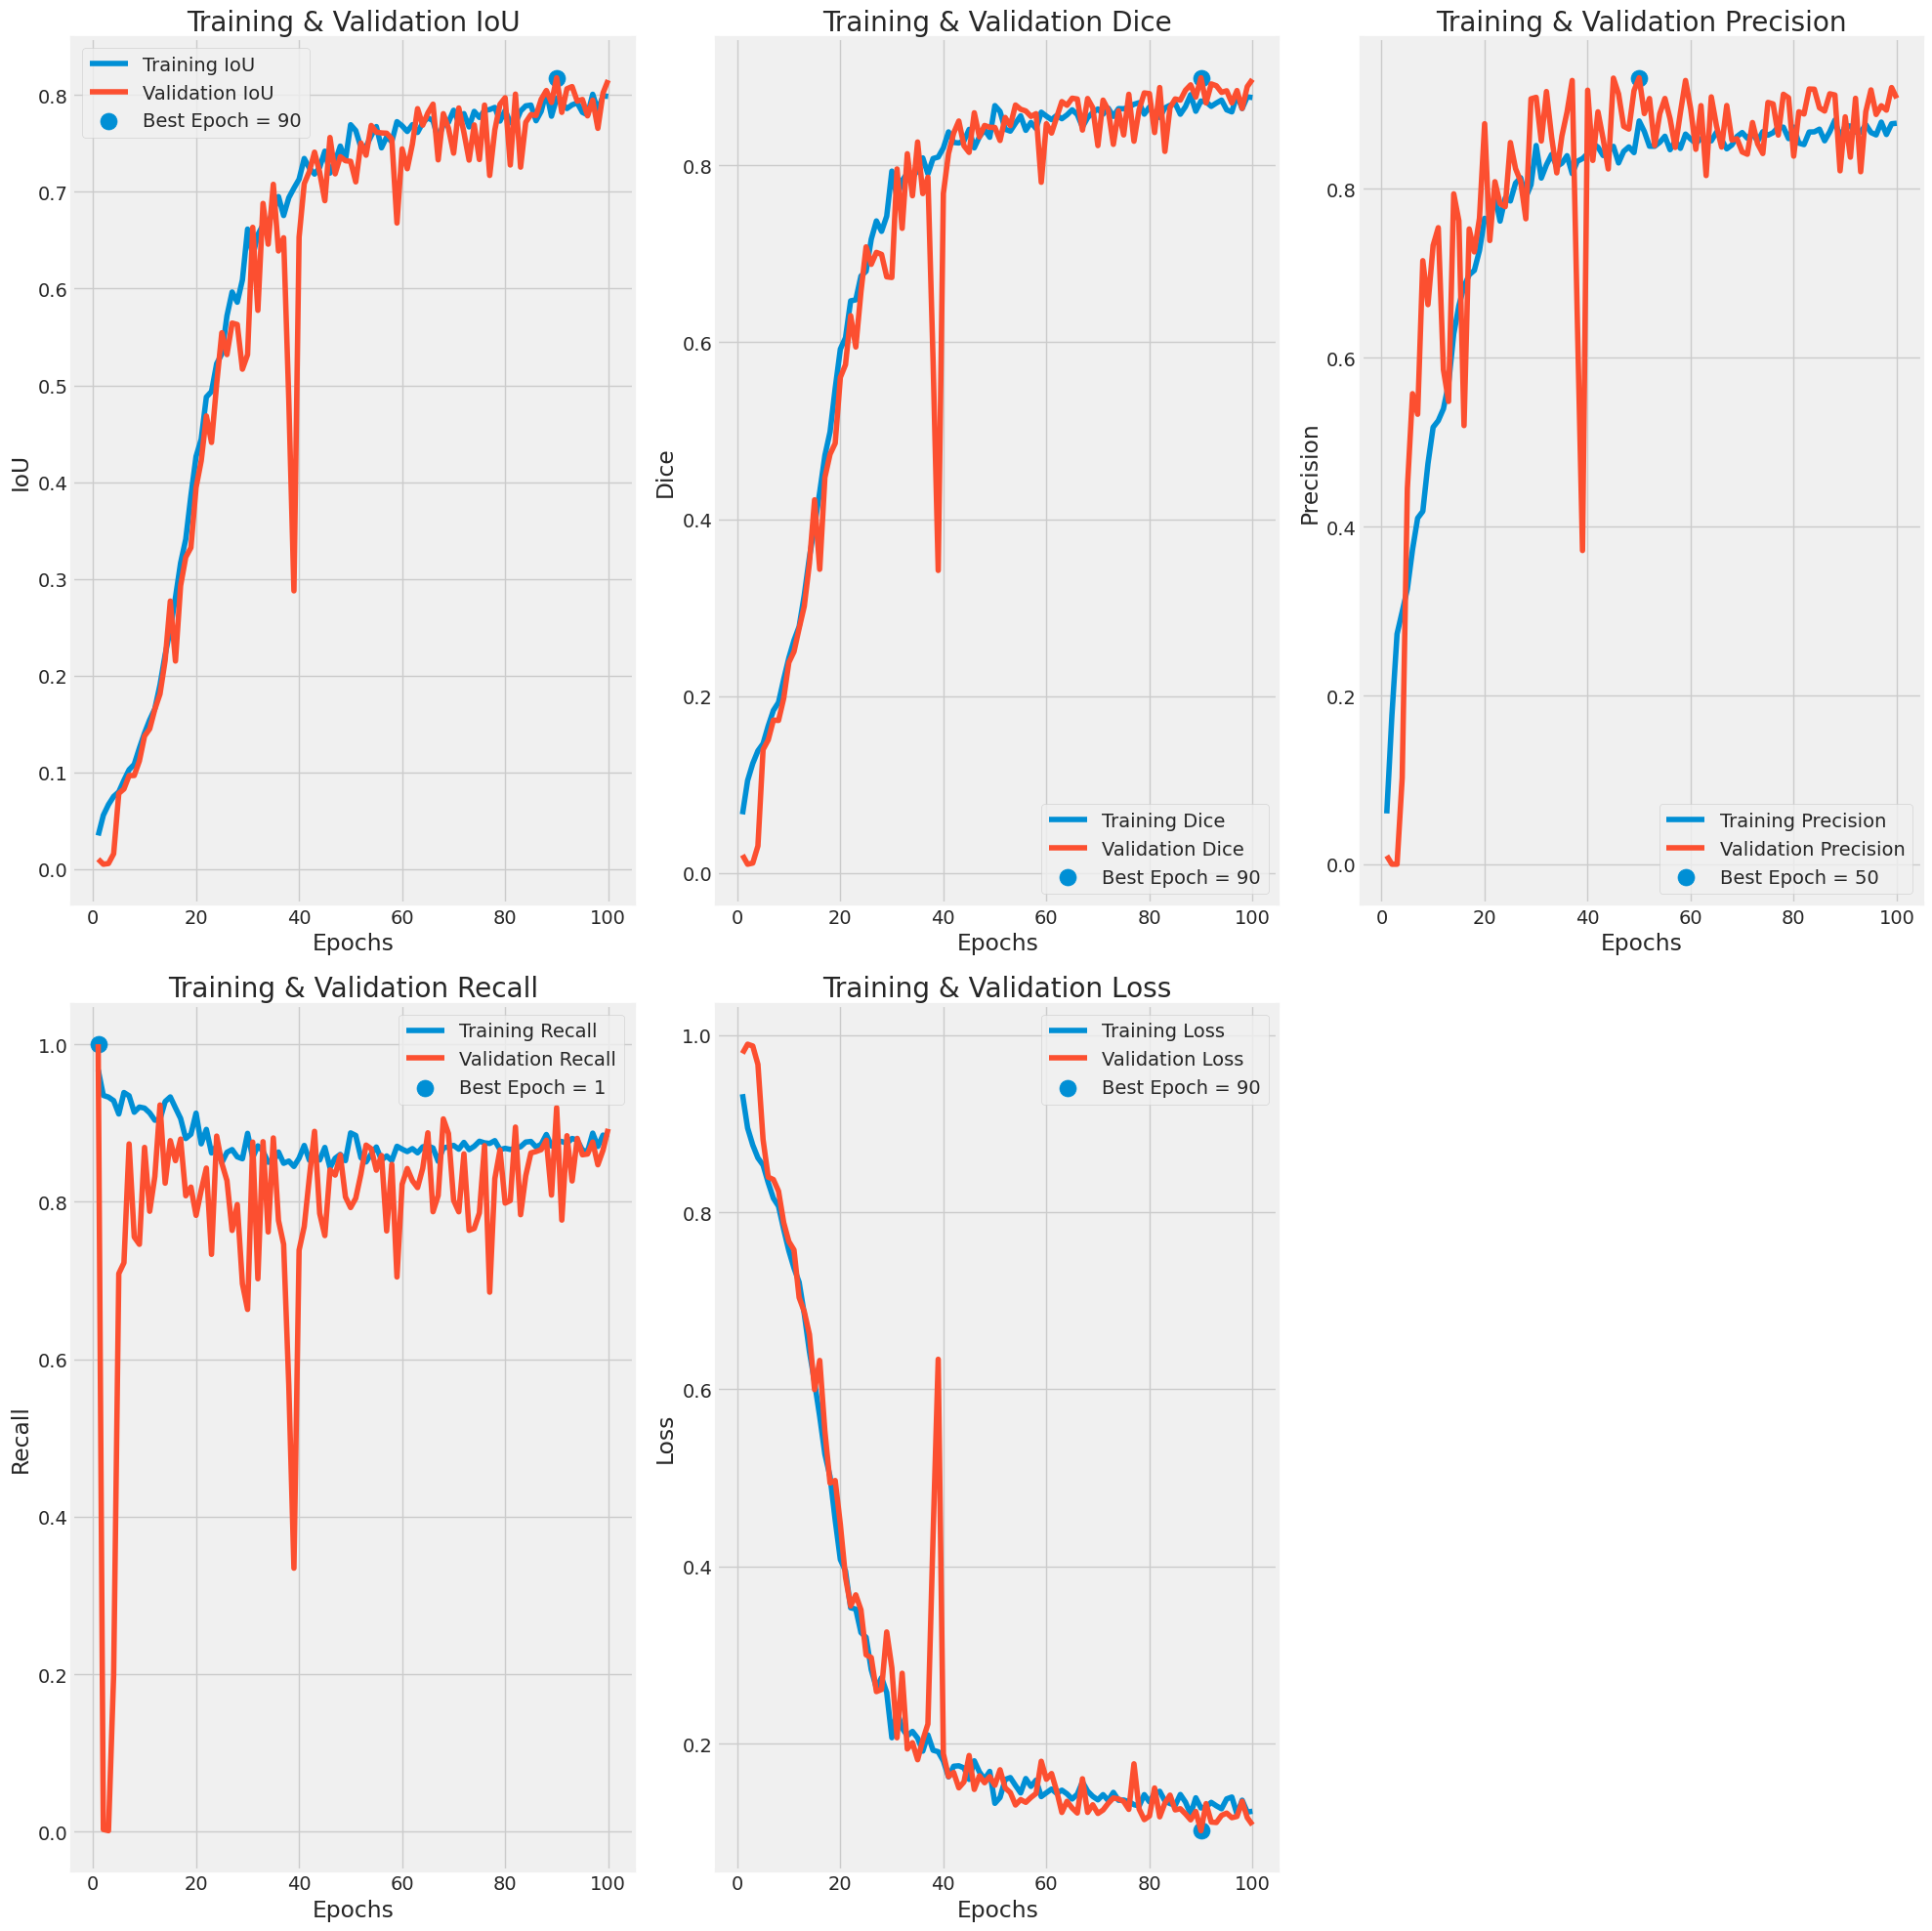

In [13]:
plot_training(history)

## Model Evaluation

In [14]:
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)


print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print("Train IoU: ", train_score[2])
print("Train Dice: ", train_score[3])
print('-' * 20)

print("Valid Loss: ", valid_score[0])
print("Valid Accuracy: ", valid_score[1])
print("Valid IoU: ", valid_score[2])
print("Valid Dice: ", valid_score[3])
print('-' * 20)

print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])
print("Test IoU: ", test_score[2])
print("Test Dice: ", test_score[3])

131/131 ━━━━━━━━━━━━━━━━━━━━ 96s 733ms/step - dice_coef: 0.9035 - iou_coef: 0.8252 - loss: 0.0965 - precision_m: 0.8907 - recall_m: 0.9234
131/131 ━━━━━━━━━━━━━━━━━━━━ 31s 235ms/step - dice_coef: 0.8827 - iou_coef: 0.7944 - loss: 0.1184 - precision_m: 0.8549 - recall_m: 0.8778
Found 393 validated image filenames.
Found 393 validated image filenames.
131/131 ━━━━━━━━━━━━━━━━━━━━ 42s 325ms/step - dice_coef: 0.8987 - iou_coef: 0.8205 - loss: 0.0988 - precision_m: 0.8760 - recall_m: 0.8803
Train Loss:  0.09487450122833252
Train Accuracy:  0.9051522016525269
Train IoU:  0.8280100226402283
Train Dice:  0.8929979801177979
--------------------
Valid Loss:  0.11813628673553467
Valid Accuracy:  0.8832435607910156
Valid IoU:  0.7946251034736633
Valid Dice:  0.8619087934494019
--------------------
Test Loss:  0.1003333181142807
Test Accuracy:  0.8976713418960571
Test IoU:  0.8200176954269409
Test Dice:  0.8655065894126892


## **Prediction**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


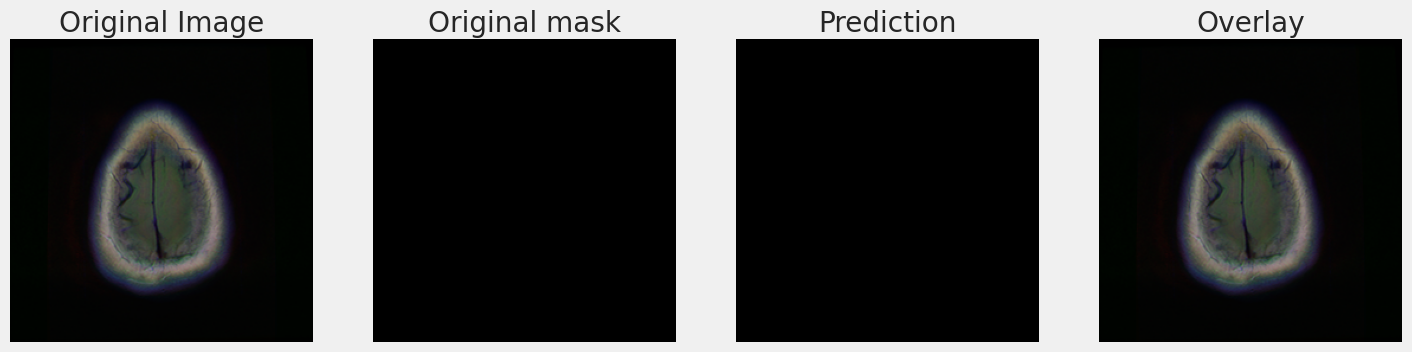

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


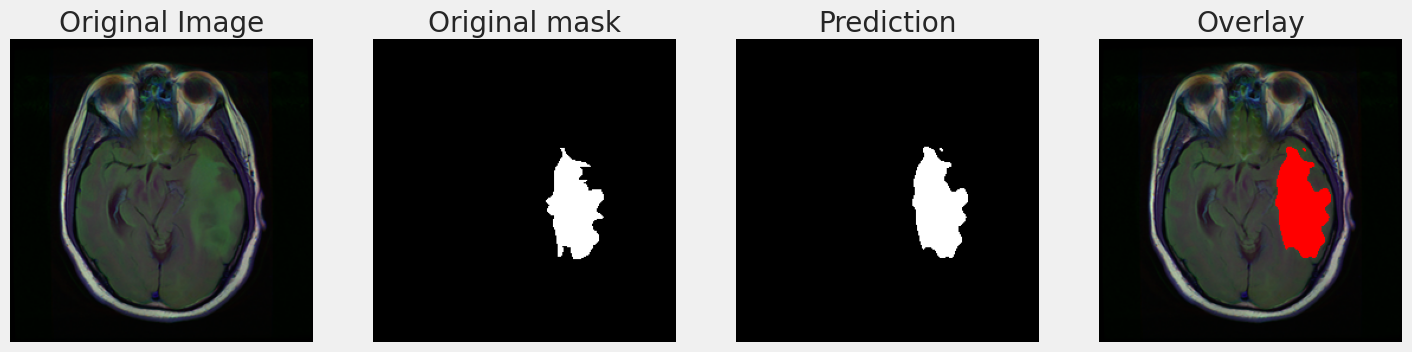

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


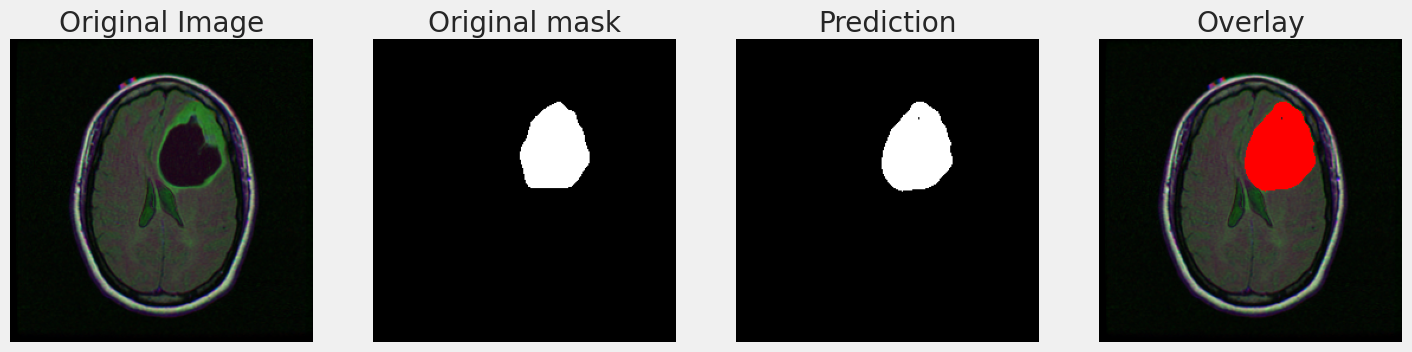

In [55]:
def visualize_prediction(model, df, num_sample=3, img_size=(256,256), threshold=0.3):
  
    for i in range(num_sample):

        index = np.random.randint(0, len(df))

        img = cv2.imread(df['images_paths'].iloc[index])
        img = cv2.resize(img, img_size)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_norm = img_rgb / 255.0
        img_input = np.expand_dims(img_norm, axis=0)

        mask = cv2.imread(df['masks_paths'].iloc[index], cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, img_size)

        pred = model.predict(img_input)[0]
        pred_binary = (pred[:,:,0] > threshold).astype(np.uint8)

        overlay = img_rgb.copy()
        overlay[pred_binary == 1] = [255, 0, 0]  

        plt.figure(figsize=(16,6))
        plt.subplot(1,4,1)
        plt.imshow(img_rgb)
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(1,4,2)
        plt.imshow(mask, cmap='gray')
        plt.title("Original mask")
        plt.axis("off")

        plt.subplot(1,4,3)
        plt.imshow(pred_binary, cmap='gray')
        plt.title("Prediction")
        plt.axis("off")

        plt.subplot(1,4,4)
        plt.imshow(overlay)
        plt.title("Overlay")
        plt.axis("off")
        plt.show()

visualize_prediction(model, df)

In [32]:
# model.save('model_unet2.keras')